# Figure demo

The cell below is tagged `#| label: figDemo`, which is what lets
`02-interactive-figures.md` embed its output with `:::{figure} #figDemo`.

This is Plotly's standard slider example. Replace it with your own work.

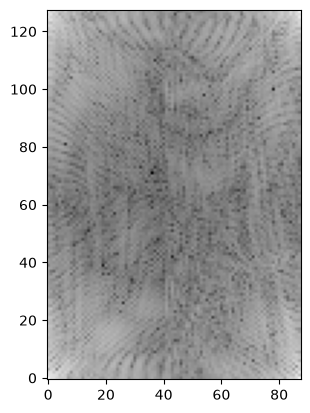

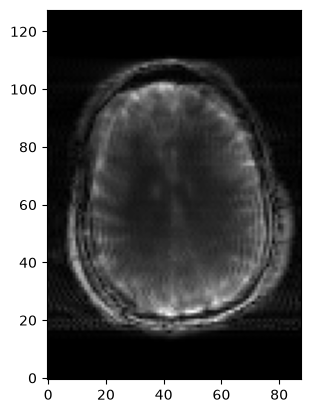

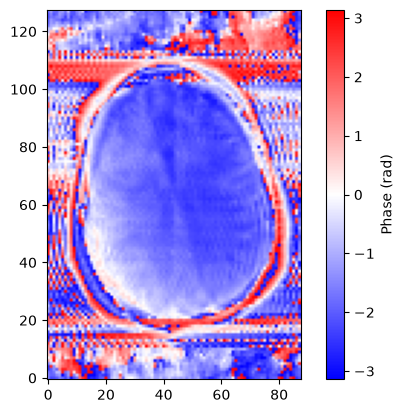

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
import nibabel as nib

PHASE = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-phase_MTS.nii.gz")
MAG = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-mag_MTS.nii.gz")

mag_data = (nib.load(MAG).get_fdata())[:,:,0]
phase_data = (nib.load(PHASE).get_fdata())[:,:,0] 
complex_img = mag_data * np.exp(1j * phase_data)
kspace = (np.fft.fft2(complex_img))
nx, ny = kspace.shape

#Assuming one full Ky line per TR
motion_start = 40   
motion_stop  = 60
angle_rate   = 1.0  #deg per line

lines = np.arange(nx)    
x_deg = np.arange(motion_stop-motion_start)   
deg = np.zeros(nx)
deg[(lines >= motion_start) & (lines < motion_stop)] = x_deg * angle_rate
kspace_rot = kspace.copy()

for i in lines[motion_start:motion_stop]:
    complex_img_rotated = (
        rotate(mag_data, deg[i], reshape=False, order=1)
        * np.exp(1j * rotate(phase_data, deg[i], reshape=False, order=1)))
    kspace_rot[i,:] = (np.fft.fft2((complex_img_rotated)))[i,:]
    
    #plt.imshow(np.abs(complex_img_rotated), cmap="gray", origin="lower")
    #plt.show()
    
for i in lines[motion_stop:]:
    complex_img_rotated = (
        rotate(mag_data, deg[motion_stop-1], reshape=False, order=1)
        * np.exp(1j * rotate(phase_data, deg[motion_stop-1], reshape=False, order=1)))
    kspace_rot[i,:] = (np.fft.fft2((complex_img_rotated)))[i,:]
    
   
img_motion = (np.fft.ifft2(kspace_rot))

plt.imshow(np.log(np.abs(kspace_rot)).T, cmap="gray", origin="lower")
plt.show()

plt.imshow(np.abs(img_motion.T), cmap="gray", origin="lower")
plt.show()

plt.imshow(np.angle(img_motion.T), cmap="bwr", vmin=-np.pi, vmax=np.pi,origin="lower")
plt.colorbar(label="Phase (rad)")
plt.show()

In [30]:
import numpy as np
import nibabel as nib
from scipy.ndimage import rotate
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import interact, IntSlider, FloatSlider

PHASE = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-phase_MTS.nii.gz")
MAG = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-mag_MTS.nii.gz")

mag_data = (nib.load(MAG).get_fdata())[:, :, 0]
phase_data = (nib.load(PHASE).get_fdata())[:, :, 0]
complex_img = mag_data * np.exp(1j * phase_data)
kspace = np.fft.fft2(complex_img)
nx, ny = kspace.shape


def update(motion_start=5, motion_stop=50, angle_rate=1.0):
    lines = np.arange(nx)
    x_deg = np.arange(max(motion_stop - motion_start, 0))
    deg = np.zeros(nx)
    deg[(lines >= motion_start) & (lines < motion_stop)] = x_deg * angle_rate

    kspace_rot = kspace.copy()
    for i in lines[motion_start:motion_stop]:
        complex_img_rotated = (
            rotate(mag_data, deg[i], reshape=False, order=1)
            * np.exp(1j * rotate(phase_data, deg[i], reshape=False, order=1))
        )
        kspace_rot[i, :] = (np.fft.fft2(complex_img_rotated))[i, :]
    for i in lines[motion_stop:]:
        complex_img_rotated = (
            rotate(mag_data, deg[motion_stop-1], reshape=False, order=1)
            * np.exp(1j * rotate(phase_data, deg[motion_stop-1], reshape=False, order=1)))
        kspace_rot[i,:] = (np.fft.fft2((complex_img_rotated)))[i,:]
    
    img_motion = np.fft.ifft2(kspace_rot)

    # mask: 1 for lines affected by motion, NaN elsewhere (NaN -> fully transparent in Heatmap)
    affected = np.full((nx, ny), np.nan)
    affected[motion_start:motion_stop, :] = 1

    fig = make_subplots(rows=1, cols=3, subplot_titles=("k-space (log|.|)", "Magnitude", "Phase"))

    fig.add_trace(go.Heatmap(z=np.log(np.abs(kspace_rot) + 1e-9).T,
                              colorscale="gray", showscale=False), row=1, col=1)
    # overlay: transparent colorscale mapped entirely to red, NaNs left transparent
    fig.add_trace(go.Heatmap(z=affected.T, colorscale=[[0, "red"], [1, "red"]],
                              showscale=False, opacity=0.35, hoverinfo="skip"), row=1, col=1)

    fig.add_trace(go.Heatmap(z=np.abs(img_motion).T, colorscale="gray", showscale=False), row=1, col=2)
    fig.add_trace(go.Heatmap(z=np.angle(img_motion).T, colorscale="RdBu", zmin=-np.pi, zmax=np.pi,
                              colorbar=dict(title="rad")), row=1, col=3)

    for c in (1, 2, 3):
        fig.update_yaxes(scaleanchor=f"x{c}" if c > 1 else "x", row=1, col=c)

    fig.update_layout(width=1050, height=420, template="plotly_white",
                       margin=dict(l=40, r=40, t=40, b=40))
    fig.show()


interact(
    update,
    motion_start=IntSlider(value=5, min=0, max=nx - 1, step=1, description="start"),
    motion_stop=IntSlider(value=50, min=1, max=nx, step=1, description="stop"),
    angle_rate=FloatSlider(value=1.0, min=-10.0, max=10.0, step=0.1, description="deg/line"),
)

interactive(children=(IntSlider(value=5, description='start', max=87), IntSlider(value=50, description='stop',…

<function __main__.update(motion_start=5, motion_stop=50, angle_rate=1.0)>